In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
games = pd.read_csv('games.csv')
games.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [3]:
teams = pd.read_csv('teams.csv')
teams.head()

,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends


In [4]:
RAW_STATS = ['PTS', 'FG_PCT', 'FT_PCT', 'FG3_PCT', 'AST', 'REB']
games['GAME_DATE_EST'] = pd.to_datetime(games['GAME_DATE_EST'])
# irrelevant to model
games = games.drop(columns=['GAME_STATUS_TEXT', 'HOME_TEAM_WINS', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID'])
# take out all of the NAs
stat_cols = [f'{s}_{side}' for s in RAW_STATS for side in ('home', 'away')]
games = games.dropna(subset=stat_cols)
games = games.sort_values(['GAME_DATE_EST', 'GAME_ID']).reset_index(drop=True)
print(games.shape)
games.head()

(26552, 17)


,GAME_DATE_EST,GAME_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away
0,2003-10-05,10300001,2003,1610612762,90.0,0.457,0.735,0.143,23.0,41.0,1610612742,85.0,0.447,0.500,0.250,20.0,38.0
1,2003-10-06,10300002,2003,1610612763,105.0,0.494,0.618,0.267,25.0,48.0,1610612749,94.0,0.427,0.700,0.154,20.0,43.0
2,2003-10-07,10300003,2003,1610612765,96.0,0.391,0.600,0.444,19.0,37.0,1610612739,100.0,0.494,0.690,0.667,25.0,52.0
3,2003-10-07,10300004,2003,1610612742,99.0,0.488,0.667,0.167,20.0,52.0,1610612753,89.0,0.408,0.727,0.350,15.0,34.0
4,2003-10-07,10300005,2003,1610612757,104.0,0.527,0.657,0.429,22.0,33.0,1610612745,80.0,0.470,0.667,0.333,10.0,37.0


In [5]:
# home slice
home = games[['GAME_ID', 'GAME_DATE_EST', 'SEASON', 'TEAM_ID_home'] + [f'{s}_home' for s in RAW_STATS]].copy()
home = home.rename(columns={f'{s}_home': s for s in RAW_STATS} | {'TEAM_ID_home': 'TEAM_ID'})
home['IS_HOME'] = 1
# away slice
away = games[['GAME_ID', 'GAME_DATE_EST', 'SEASON', 'TEAM_ID_away'] + [f'{s}_away' for s in RAW_STATS]].copy()
away = away.rename(columns={f'{s}_away': s for s in RAW_STATS} | {'TEAM_ID_away': 'TEAM_ID'})
away['IS_HOME'] = 0

game_per_team = pd.concat([home, away], ignore_index=True)
print(game_per_team.shape)
game_per_team.head()

(53104, 11)


,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB,IS_HOME
0,10300001,2003-10-05,2003,1610612762,90.0,0.457,0.735,0.143,23.0,41.0,1
1,10300002,2003-10-06,2003,1610612763,105.0,0.494,0.618,0.267,25.0,48.0,1
2,10300003,2003-10-07,2003,1610612765,96.0,0.391,0.600,0.444,19.0,37.0,1
3,10300004,2003-10-07,2003,1610612742,99.0,0.488,0.667,0.167,20.0,52.0,1
4,10300005,2003-10-07,2003,1610612757,104.0,0.527,0.657,0.429,22.0,33.0,1


In [6]:
game_per_team = game_per_team.sort_values(['TEAM_ID', 'GAME_DATE_EST', 'GAME_ID']).reset_index(drop=True)

ROLL_COLS = [f'{s}_roll10' for s in RAW_STATS]

for s, col in zip(RAW_STATS, ROLL_COLS):
    # shift 1 to not include current game
    game_per_team[col] = (
        game_per_team.groupby('TEAM_ID')[s].transform(lambda x: x.shift(1).rolling(10, min_periods=10).mean())
    )
game_per_team = game_per_team.dropna(subset=ROLL_COLS).reset_index(drop=True)
print(game_per_team.shape)
game_per_team.head()

(52804, 17)


,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB,IS_HOME,PTS_roll10,FG_PCT_roll10,FT_PCT_roll10,FG3_PCT_roll10,AST_roll10,REB_roll10
0,20300128,2003-11-15,2003,1610612737,85.0,0.382,0.767,0.333,19.0,39.0,1,89.4,0.4327,0.7390,0.3765,20.1,44.0
1,20300141,2003-11-17,2003,1610612737,97.0,0.423,0.872,0.231,12.0,39.0,1,89.9,0.4359,0.7407,0.3669,20.2,43.4
2,20300147,2003-11-18,2003,1610612737,101.0,0.458,0.875,0.286,22.0,48.0,0,91.3,0.4384,0.7542,0.3686,19.6,41.5
3,20300168,2003-11-21,2003,1610612737,75.0,0.338,0.769,0.125,11.0,41.0,0,92.0,0.4442,0.7703,0.3389,19.6,41.5
4,20300177,2003-11-22,2003,1610612737,92.0,0.447,0.933,0.200,25.0,45.0,1,89.6,0.4312,0.7795,0.3139,18.4,42.0


In [7]:
home_agg = game_per_team[game_per_team['IS_HOME'] == 1][['GAME_ID', 'TEAM_ID'] + ROLL_COLS].copy()
home_agg = home_agg.rename(columns={c: f'{c}_home' for c in ROLL_COLS} | {'TEAM_ID': 'TEAM_ID_home'})
away_agg = game_per_team[game_per_team['IS_HOME'] == 0][['GAME_ID', 'TEAM_ID'] + ROLL_COLS].copy()
away_agg = away_agg.rename(columns={c: f'{c}_away' for c in ROLL_COLS} | {'TEAM_ID': 'TEAM_ID_away'})

In [8]:
base = games[['GAME_ID', 'GAME_DATE_EST', 'SEASON', 'TEAM_ID_home', 'TEAM_ID_away', 'PTS_home', 'PTS_away']].copy()
# what we are predicting for
base['POINT_DIFF'] = base['PTS_home'] - base['PTS_away']
base = base.drop(columns=['PTS_home', 'PTS_away'])
# inner join to make sure no NAs
model_df = (
    base
    .merge(home_agg, on=['GAME_ID', 'TEAM_ID_home'], how='inner')
    .merge(away_agg, on=['GAME_ID', 'TEAM_ID_away'], how='inner')
)
# add nicknames/natural language team name
nick = teams[['TEAM_ID', 'NICKNAME']]
model_df = (
    model_df
    .merge(nick.rename(columns={'TEAM_ID': 'TEAM_ID_home', 'NICKNAME': 'NICKNAME_home'}),
           on='TEAM_ID_home', how='inner')
    .merge(nick.rename(columns={'TEAM_ID': 'TEAM_ID_away', 'NICKNAME': 'NICKNAME_away'}),
           on='TEAM_ID_away', how='inner')
)
# clean up the roles
roll_home = [f'{c}_home' for c in ROLL_COLS]
roll_away = [f'{c}_away' for c in ROLL_COLS]
col_order = (['GAME_ID', 'GAME_DATE_EST', 'SEASON', 'NICKNAME_home', 'NICKNAME_away', 'TEAM_ID_home', 'TEAM_ID_away']
             + roll_home + roll_away + ['POINT_DIFF'])
model_df = model_df[col_order]
print(model_df.shape)
model_df.head()

(26561, 20)


,GAME_ID,GAME_DATE_EST,SEASON,NICKNAME_home,NICKNAME_away,TEAM_ID_home,TEAM_ID_away,PTS_roll10_home,FG_PCT_roll10_home,FT_PCT_roll10_home,FG3_PCT_roll10_home,AST_roll10_home,REB_roll10_home,PTS_roll10_away,FG_PCT_roll10_away,FT_PCT_roll10_away,FG3_PCT_roll10_away,AST_roll10_away,REB_roll10_away,POINT_DIFF
0,20300127,2003-11-15,2003,Wizards,Spurs,1610612764,1610612759,92.8,0.4395,0.7134,0.3308,20.6,44.6,86.4,0.3806,0.7503,0.2891,18.3,46.8,-24.0
1,20300128,2003-11-15,2003,Hawks,Nets,1610612737,1610612751,89.4,0.4327,0.7390,0.3765,20.1,44.0,86.0,0.4149,0.7358,0.3413,23.9,40.2,-15.0
2,20300130,2003-11-15,2003,Cavaliers,76ers,1610612739,1610612755,89.5,0.4405,0.6874,0.3291,23.3,45.7,93.2,0.4382,0.7238,0.3170,19.6,38.3,3.0
3,20300136,2003-11-16,2003,Raptors,Rockets,1610612761,1610612745,75.3,0.3821,0.7709,0.2969,17.8,40.8,87.7,0.4390,0.7576,0.3872,17.4,41.7,4.0
4,20300139,2003-11-17,2003,76ers,Rockets,1610612755,1610612745,94.1,0.4390,0.7082,0.3209,20.5,38.9,89.4,0.4289,0.7770,0.3789,17.5,42.4,-8.0


In [9]:
model_df.to_csv('games_clean.csv', index=False)

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

START_SEASON = 2015 
N_SEASONS = 5  

TRAIN_SEASONS = list(range(START_SEASON, START_SEASON + N_SEASONS))
TEST_SEASON = START_SEASON + N_SEASONS

train_df = (
    model_df[model_df['SEASON'].isin(TRAIN_SEASONS)]
    .sort_values(['GAME_DATE_EST', 'GAME_ID'])
    .reset_index(drop=True)
)

# in test data, first instance of each ordered
# (home, away) pair, 30 teams, so 30x29 = 870 rows
next_season = (
    model_df[model_df['SEASON'] == TEST_SEASON].sort_values(['GAME_DATE_EST', 'GAME_ID'])
)
# we only want 1st instance of (teamA, teamB) for predictions
test_df = (
    next_season.drop_duplicates(subset=['TEAM_ID_home', 'TEAM_ID_away'], keep='first')
    .reset_index(drop=True)
)

print(f'Training seasons: {TRAIN_SEASONS}')
print(f'Test season: {TEST_SEASON}')
print(f'train_df shape: {train_df.shape}')
print(f'test_df shape: {test_df.shape}')

Training seasons: [2015, 2016, 2017, 2018, 2019]
Test season: 2020
train_df shape: (6822, 20)
test_df shape: (870, 20)


In [29]:
ROLL_FEATURE_COLS = [f'{c}_home' for c in ROLL_COLS] + [f'{c}_away' for c in ROLL_COLS]

scaler = StandardScaler().fit(train_df[ROLL_FEATURE_COLS])
train_roll = scaler.transform(train_df[ROLL_FEATURE_COLS])
test_roll  = scaler.transform(test_df[ROLL_FEATURE_COLS])

ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.fit(np.concatenate([
    train_df['NICKNAME_home'].to_numpy().reshape(-1,1),
    train_df['NICKNAME_away'].to_numpy().reshape(-1,1),
]))

train_home_oh = ohe.transform(train_df[['NICKNAME_home']].to_numpy())
train_away_oh = ohe.transform(train_df[['NICKNAME_away']].to_numpy())
test_home_oh  = ohe.transform(test_df[['NICKNAME_home']].to_numpy())
test_away_oh  = ohe.transform(test_df[['NICKNAME_away']].to_numpy())

In [31]:
X_train = np.hstack([train_roll, train_home_oh, train_away_oh])
X_test  = np.hstack([test_roll,  test_home_oh,  test_away_oh])
y_train = train_df['POINT_DIFF'].to_numpy().reshape(-1,1)
y_test  = test_df['POINT_DIFF'].to_numpy().reshape(-1,1)

feature_names = (
    # since drop first we don't include first category
    ROLL_FEATURE_COLS + [f'HOME_{t}' for t in ohe.categories_[0][1:]] + [f'AWAY_{t}' for t in ohe.categories_[0][1:]]
)
print('Dropped category:', ohe.categories_[0][1])
print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test:', X_test.shape, ' y_test:', y_test.shape)

pd.DataFrame(X_train, columns=feature_names).to_csv('train-test/X_train.csv', index=False)
pd.DataFrame(X_test, columns=feature_names).to_csv('train-test/X_test.csv', index=False)
pd.DataFrame(y_train, columns=['POINT_DIFF']).to_csv('train-test/y_train.csv', index=False)
pd.DataFrame(y_test, columns=['POINT_DIFF']).to_csv('train-test/y_test.csv', index=False)

Dropped category: Bucks
X_train: (6822, 70)  y_train: (6822, 1)
X_test: (870, 70)  y_test:  (870, 1)


,PTS_roll10_home,FG_PCT_roll10_home,FT_PCT_roll10_home,FG3_PCT_roll10_home,AST_roll10_home,REB_roll10_home,PTS_roll10_away,FG_PCT_roll10_away,FT_PCT_roll10_away,FG3_PCT_roll10_away,...,AWAY_Pistons,AWAY_Raptors,AWAY_Rockets,AWAY_Spurs,AWAY_Suns,AWAY_Thunder,AWAY_Timberwolves,AWAY_Trail Blazers,AWAY_Warriors,AWAY_Wizards
0,0.599234,0.752170,-1.747627,-1.477152,0.220095,0.055354,0.494449,-0.084336,0.184646,0.088640,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-2.116161,-0.624237,-0.088128,-1.863403,-0.829544,0.373132,-2.866007,-2.722380,-0.272590,-1.679444,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.902577,-0.131395,-1.183445,2.616467,-0.431405,0.973380,-1.178244,-0.484713,-0.464487,-0.198752,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.585218,-1.072679,-1.839691,0.036189,-0.648572,-0.615511,-1.298799,-0.569238,-1.286564,-0.489267,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.251482,-0.917278,0.402876,-0.701486,-1.481044,-0.933289,0.509518,0.471744,-1.405019,-0.823516,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6817,1.115007,2.359457,0.511463,0.520585,1.233540,-0.509585,0.524587,-0.115476,1.655856,-0.467400,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6818,0.538555,0.166087,1.934903,-0.375389,1.124957,-1.427611,1.187637,2.068807,0.452354,0.166736,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6819,0.538555,0.472448,1.965591,-0.403883,0.835401,-1.568846,1.067082,1.530521,0.601607,0.166736,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6820,0.978479,1.347133,0.414679,0.378115,1.052568,-0.756746,0.404033,0.218172,1.707977,-0.454905,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
# can reduce features by only using differentials
DIFF_COLS = [f'{s}_roll10_diff' for s in RAW_STATS]

train_diff_raw = (train_df[[f'{c}_home' for c in ROLL_COLS]].to_numpy() - train_df[[f'{c}_away' for c in ROLL_COLS]].to_numpy())
test_diff_raw = (test_df[[f'{c}_home' for c in ROLL_COLS]].to_numpy() - test_df[[f'{c}_away' for c in ROLL_COLS]].to_numpy())

scaler_diff = StandardScaler().fit(train_diff_raw)
train_roll_diff = scaler_diff.transform(train_diff_raw)
test_roll_diff = scaler_diff.transform(test_diff_raw)

X_train_diff = np.hstack([train_roll_diff, train_home_oh, train_away_oh])
X_test_diff = np.hstack([test_roll_diff,  test_home_oh,  test_away_oh])

feature_names_roll = (
    DIFF_COLS + [f'HOME_{t}' for t in ohe.categories_[0][1:]] + [f'AWAY_{t}' for t in ohe.categories_[0][1:]]
)
print('X_train_diff:', X_train_roll.shape, ' X_test_diff:', X_test_roll.shape)

X_train_diff: (6822, 64)  X_test_diff: (870, 64)


In [38]:
train_roll_df = pd.DataFrame(X_train_roll, columns=feature_names_roll)
test_roll_df = pd.DataFrame(X_test_roll, columns=feature_names_roll)

train_roll_df.to_csv('train-test/X_train_diff.csv', index=False)
test_roll_df.to_csv('train-test/X_test_diff.csv', index=False)

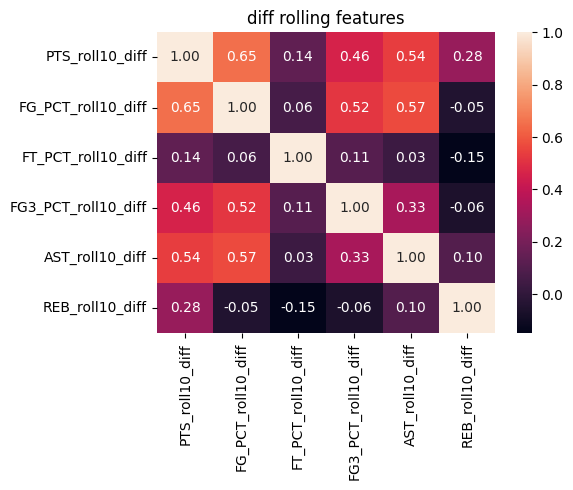

In [59]:
diff_df = pd.DataFrame(
    train_df[[f'{c}_home' for c in ROLL_COLS]].to_numpy() - train_df[[f'{c}_away' for c in ROLL_COLS]].to_numpy(),
    columns=DIFF_COLS
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(diff_df.corr(), annot=True, fmt='.2f', ax=ax)
ax.set_title('diff rolling features')
plt.tight_layout()
plt.show()